# DL Project - Trusted vs Suspicious Detection



## 1. Imports

In [34]:
import pandas as pd
import numpy as np
import re
import os
import cv2

from openpyxl import load_workbook

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Conv2D, MaxPooling2D, Flatten, Dropout


## 2. Load Data

In [3]:
import pandas as pd

sheet_id = "1__DHGbusjsXaSVwOUga4mA788KHBnb8a"  # الـ ID الصح

url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=xlsx"

data = pd.read_excel(url, engine="openpyxl")

data = data.drop_duplicates().reset_index(drop=True)

print("Data shape:", data.shape)
print(data.head())

Data shape: (671, 17)
   id     source category                                              title  \
0   1  amazon.eg   mobile  Apple iPhone 17 Pro Max (256 GB) - Cosmic Oran...   
1   2  amazon.eg   mobile  Apple iPhone 16 (128 GB) - White with Face ID ...   
2   3  amazon.eg   mobile     Apple iPhone 16 Pro (128 GB) - Desert Titanium   
3   4  amazon.eg   mobile  Apple iPhone 16 Plus (128 GB) - Blue with Face...   
4   5  amazon.eg   mobile  Apple iPhone 17 Pro (256 GB) - Deep Blue with ...   

                                         description      price  \
0  UNIBODY DESIGN. FOR EXCEPTIONAL POWER.—Heat-fo...  98777..00   
1  6.1-inch Super Retina XDR display with Dynamic...  65000..00   
2  STUNNING TITANIUM DESIGN—iPhone 16 Pro has a s...  83212..00   
3  Expansive 6.7-inch Super Retina XDR display wi...        NaN   
4  UNIBODY DESIGN. FOR EXCEPTIONAL POWER. — Heat-...  97500..00   

  original_price  discount_percent  \
0      98777..00                 0   
1      65000..00  

## 3. Preprocessing

In [4]:
# =========================
# 3. Preprocessing
# =========================

def clean_number(value):
    if pd.isna(value):
        return np.nan

    value = str(value)
    value = value.replace('\n', ' ')
    value = value.replace('\r', ' ')
    value = value.replace(',', '')
    value = value.replace('EGP', '')
    value = value.replace('جنيه', '')
    value = value.replace('..', '.')
    value = value.strip()

    return pd.to_numeric(value, errors='coerce')


numeric_cols = [
    'seller_rating',
    'product_rating',
    'seller_reviews_count',
    'discount_percent',
    'price',
    'original_price'
]

for col in numeric_cols:
    if col in data.columns:
        data[col] = data[col].apply(clean_number)


text_cols = ['title', 'description', 'reviews', 'seller_name', 'image_url']

for col in text_cols:
    if col in data.columns:
        data[col] = (
            data[col]
            .astype(str)
            .str.replace('\n', ' ', regex=False)
            .str.replace('\r', ' ', regex=False)
            .str.replace(',', ' ', regex=False)
            .str.strip()
        )


data['discount_percent'] = data['discount_percent'].fillna(0)
data['price'] = data['price'].fillna(0)
data['original_price'] = data['original_price'].fillna(0)

data['price_diff'] = np.where(
    (data['price'] > 0) & (data['original_price'] > 0),
    data['original_price'] - data['price'],
    0
)

data['real_discount'] = np.where(
    (data['price'] > 0) & (data['original_price'] > 0),
    (data['price_diff'] / data['original_price']) * 100,
    0
)

data['real_discount'] = (
    data['real_discount']
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

data = data.dropna(subset=[
    'seller_rating',
    'seller_reviews_count',
    'product_rating'
]).reset_index(drop=True)

print(data[['price', 'original_price', 'price_diff', 'real_discount']].head(10))
print("Data shape after cleaning:", data.shape)

      price  original_price  price_diff  real_discount
0   98777.0         98777.0         0.0       0.000000
1   65000.0         65000.0         0.0       0.000000
2   83212.0         83212.0         0.0       0.000000
3       0.0             0.0         0.0       0.000000
4   97500.0         97500.0         0.0       0.000000
5  102807.0        102807.0         0.0       0.000000
6   72599.0         79000.0      6401.0       8.102532
7   94999.0         94999.0         0.0       0.000000
8       0.0             0.0         0.0       0.000000
9   72599.0         79000.0      6401.0       8.102532
Data shape after cleaning: (530, 19)


## 4. Text Cleaning

In [5]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['title'] = data['title'].apply(clean_text)
data['description'] = data['description'].apply(clean_text)

if 'reviews' not in data.columns:
    data['reviews'] = ""

data['reviews'] = data['reviews'].fillna("").apply(clean_text)

print(data[['title', 'description', 'reviews']].head())


                                               title  \
0  apple iphone pro max gb cosmic orange with fac...   
1  apple iphone gb white with face id tax paid ye...   
2                apple iphone pro gb desert titanium   
3  apple iphone plus gb blue with face id tax pai...   
4  apple iphone pro gb deep blue with face id tax...   

                                         description  \
0  unibody design for exceptional power heat forg...   
1  inch super retina xdr display with dynamic isl...   
2  stunning titanium design iphone pro has a stro...   
3  expansive inch super retina xdr display with d...   
4  unibody design for exceptional power heat forg...   

                                             reviews  
0  ممتاز تجاوز التوقعات التليفون لا يعمل ودخل فى ...  
1  overall experience of the mobile phone is good...  
2  the best i phone it s really amazing specialy ...  
3  من فضل حضرتك عايزه الفاتوره الضريبية lieferzei...  
4                       المنتج غير هو صحيح كوبي كوب

## 5. Remove Extreme Values

In [6]:
for col in ['seller_rating', 'product_rating', 'seller_reviews_count']:
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    data = data[(data[col] >= lower) & (data[col] <= upper)]

data = data.reset_index(drop=True)
print("Data shape after removing outliers:", data.shape)


Data shape after removing outliers: (524, 19)


## 6. Feature Engineering

In [7]:

# review features
data['review_len'] = data['reviews'].apply(lambda x: len(x.split()))

suspicious_words = ['fake', 'bad', 'poor', 'worst', 'scam', 'مش', 'سيء', 'وحش']

def count_suspicious(text):
    return sum(word in text for word in suspicious_words)

data['suspicious_score'] = data['reviews'].apply(count_suspicious)

# verified column
if 'is_verified' in data.columns:
    data['is_verified'] = data['is_verified'].apply(lambda x: 1 if x == True else 0)
else:
    data['is_verified'] = 0

data[['seller_rating','product_rating','seller_reviews_count','real_discount','suspicious_score']].head()


,seller_rating,product_rating,seller_reviews_count,real_discount,suspicious_score
0,3.8,3.8,40,0.0,1
1,4.6,4.6,2376,0.0,0
2,4.4,4.4,39,0.0,0
3,4.6,4.6,654,0.0,0
4,4.1,4.1,43,0.0,0


## 7. Labeling 


In [8]:
low_seller_rating = data['seller_rating'].quantile(0.25)
low_product_rating = data['product_rating'].quantile(0.25)
low_seller_reviews_count = data['seller_reviews_count'].quantile(0.50)

non_zero_discount = data[data['real_discount'] > 0]['real_discount']
if len(non_zero_discount) > 0:
    high_discount = non_zero_discount.quantile(0.75)
else:
    high_discount = data['real_discount'].quantile(0.75)

print("Thresholds used:")
print("Low seller rating:", low_seller_rating)
print("Low product rating:", low_product_rating)
print("Low seller reviews count:", low_seller_reviews_count)
print("High discount:", high_discount)

def create_label(row):
    score = 0

    if row['seller_rating'] < low_seller_rating:
        score += 1

    if row['product_rating'] < low_product_rating:
        score += 1

    if row['seller_reviews_count'] < low_seller_reviews_count:
        score += 1

    if row['real_discount'] > high_discount:
        score += 1

    if row['suspicious_score'] > 0:
        score += 1

    # 1 = Suspicious, 0 = Trusted
    return 1 if score >= 2 else 0

data['label'] = data.apply(create_label, axis=1)
print(data['label'].value_counts())


Thresholds used:
Low seller rating: 3.9
Low product rating: 3.9
Low seller reviews count: 51.5
High discount: 15.596575708935259
label
0    375
1    149
Name: count, dtype: int64


In [9]:
from google.colab import files

df_save = data.copy()
for col in df_save.select_dtypes(include='object').columns:
    df_save[col] = df_save[col].astype(str).str.replace('\n', ' ').str.replace('\r', ' ').str.strip()

df_save.to_excel("labeled_data.xlsx", index=False)
files.download("labeled_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Extract Images From Excel

In [10]:
from google.colab import drive
import os
import imghdr
from openpyxl import load_workbook

drive.mount('/content/drive', force_remount=False)
file_path = "/content/drive/MyDrive/Scraping data.xlsx"

wb = load_workbook(file_path)
ws = wb.active

os.makedirs("images", exist_ok=True)
image_paths = []

for i, img_obj in enumerate(ws._images):
    img_data = img_obj._data()
    img_type = imghdr.what(None, h=img_data)
    ext = img_type if img_type else "png"
    path = f"images/img_{i}.{ext}"
    with open(path, "wb") as f:
        f.write(img_data)
    image_paths.append(path)

print("Number of photos:", len(image_paths))
print("Number of rows:", len(data))

min_len = min(len(image_paths), len(data))
data = data.iloc[:min_len].copy().reset_index(drop=True)
data['image_path'] = image_paths[:min_len]

print("Final data shape:", data.shape)
print(data.columns.tolist())

/tmp/ipykernel_2584/1096078525.py:3: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Mounted at /content/drive
Number of photos: 672
Number of rows: 524
Final data shape: (524, 24)
['id', 'source', 'category', 'title', 'description', 'price', 'original_price', 'discount_percent', 'image_url', 'seller_name', 'seller_rating', 'seller_reviews_count', 'product_rating', 'reviews_count', 'reviews', 'location', 'image', 'price_diff', 'real_discount', 'review_len', 'suspicious_score', 'is_verified', 'label', 'image_path']


In [11]:
import numpy as np
import re

# ── إعادة الـ preprocessing ──
def clean_number(value):
    if pd.isna(value):
        return np.nan
    value = str(value).replace('\n', ' ').replace(',', '').replace('EGP', '').replace('جنيه', '').replace('..', '.').strip()
    return pd.to_numeric(value, errors='coerce')

for col in ['seller_rating', 'product_rating', 'seller_reviews_count', 'discount_percent', 'price', 'original_price']:
    if col in data.columns:
        data[col] = data[col].apply(clean_number)

data['discount_percent'] = data['discount_percent'].fillna(0)
data['price'] = data['price'].fillna(0)
data['original_price'] = data['original_price'].fillna(0)

data['price_diff'] = np.where((data['price'] > 0) & (data['original_price'] > 0), data['original_price'] - data['price'], 0)
data['real_discount'] = np.where((data['price'] > 0) & (data['original_price'] > 0), (data['price_diff'] / data['original_price']) * 100, 0)
data['real_discount'] = data['real_discount'].replace([np.inf, -np.inf], np.nan).fillna(0)

data = data.dropna(subset=['seller_rating', 'seller_reviews_count', 'product_rating']).reset_index(drop=True)

# ── text cleaning ──
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

data['title'] = data['title'].apply(clean_text)
data['description'] = data['description'].apply(clean_text)
data['reviews'] = data['reviews'].fillna("").apply(clean_text)

# ── suspicious score ──
suspicious_words = ['fake', 'bad', 'poor', 'worst', 'scam', 'مش', 'سيء', 'وحش']
data['suspicious_score'] = data['reviews'].apply(lambda x: sum(word in x for word in suspicious_words))
data['is_verified'] = 0

# ── labeling ──
low_seller_rating = data['seller_rating'].quantile(0.25)
low_product_rating = data['product_rating'].quantile(0.25)
low_seller_reviews_count = data['seller_reviews_count'].quantile(0.50)
non_zero_discount = data[data['real_discount'] > 0]['real_discount']
high_discount = non_zero_discount.quantile(0.75) if len(non_zero_discount) > 0 else data['real_discount'].quantile(0.75)

def create_label(row):
    score = 0
    if row['seller_rating'] < low_seller_rating: score += 1
    if row['product_rating'] < low_product_rating: score += 1
    if row['seller_reviews_count'] < low_seller_reviews_count: score += 1
    if row['real_discount'] > high_discount: score += 1
    if row['suspicious_score'] > 0: score += 1
    return 1 if score >= 2 else 0

data['label'] = data.apply(create_label, axis=1)

print("Data shape:", data.shape)
print(data['label'].value_counts())
print(data[['label', 'image_path', 'real_discount']].head())

Data shape: (524, 24)
label
0    375
1    149
Name: count, dtype: int64
   label        image_path  real_discount
0      1  images/img_0.png            0.0
1      0  images/img_1.png            0.0
2      0  images/img_2.png            0.0
3      0  images/img_3.png            0.0
4      0  images/img_4.png            0.0


## 9. Prepare Text Data

In [12]:
data['combined_text'] = (
    data['title'].fillna('').astype(str) + ' ' +
    data['description'].fillna('').astype(str) + ' ' +
    data['reviews'].fillna('').astype(str)
)

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(data['combined_text'])

sequences = tokenizer.texts_to_sequences(data['combined_text'])
X_text = pad_sequences(sequences, maxlen=100)

print("X_text shape:", X_text.shape)


X_text shape: (524, 100)


In [13]:
print(data.columns.tolist())
print(data.head())

['id', 'source', 'category', 'title', 'description', 'price', 'original_price', 'discount_percent', 'image_url', 'seller_name', 'seller_rating', 'seller_reviews_count', 'product_rating', 'reviews_count', 'reviews', 'location', 'image', 'price_diff', 'real_discount', 'review_len', 'suspicious_score', 'is_verified', 'label', 'image_path', 'combined_text']
   id     source category                                              title  \
0   1  amazon.eg   mobile  apple iphone pro max gb cosmic orange with fac...   
1   2  amazon.eg   mobile  apple iphone gb white with face id tax paid ye...   
2   3  amazon.eg   mobile                apple iphone pro gb desert titanium   
3   4  amazon.eg   mobile  apple iphone plus gb blue with face id tax pai...   
4   5  amazon.eg   mobile  apple iphone pro gb deep blue with face id tax...   

                                         description    price  original_price  \
0  unibody design for exceptional power heat forg...  98777.0         98777.0   
1

## 10. Prepare Image Data

In [14]:
def load_image(path):
    img = cv2.imread(path)

    if img is None:
        try:
            import matplotlib.image as mpimg
            img = mpimg.imread(path)
            if img is not None:
                img = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2BGR) \
                      if img.max() <= 1.0 else cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2BGR)
        except:
            return None

    if img is None:
        return None

    img = cv2.resize(img, (224, 224))
    img = img / 255.0
    return img

valid_images = []
valid_indexes = []

for idx, path in enumerate(data['image_path']):
    img = load_image(path)
    if img is not None:
        valid_images.append(img)
        valid_indexes.append(idx)

X_images = np.array(valid_images)
data = data.iloc[valid_indexes].reset_index(drop=True)
X_text = X_text[valid_indexes]


y = data['label'].astype(int).values

print("X_text:", X_text.shape)
print("X_images:", X_images.shape)
print("y:", y.shape)
print(data['label'].value_counts())


X_text: (524, 100)
X_images: (524, 224, 224, 3)
y: (524,)
label
0    375
1    149
Name: count, dtype: int64


In [15]:
print(data.columns.tolist())

['id', 'source', 'category', 'title', 'description', 'price', 'original_price', 'discount_percent', 'image_url', 'seller_name', 'seller_rating', 'seller_reviews_count', 'product_rating', 'reviews_count', 'reviews', 'location', 'image', 'price_diff', 'real_discount', 'review_len', 'suspicious_score', 'is_verified', 'label', 'image_path', 'combined_text']


## 11. Train/Test Split

In [16]:
indices = np.arange(len(data))

X_text_train, X_text_test, X_img_train, X_img_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text,
    X_images,
    y,
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_text_train.shape, X_text_test.shape)
print(X_img_train.shape, X_img_test.shape)
print(y_train.shape, y_test.shape)


(419, 100) (105, 100)
(419, 224, 224, 3) (105, 224, 224, 3)
(419,) (105,)


##12.Text Models: LSTM vs Transformer

### Architecture Justification

**LSTM — chosen for sequential pattern detection:**
- Input: padded sequences of max 100 tokens
- Embedding dim = 64 (balances vocab size 10,000 with model capacity)
- Hidden units = 32 (prevents overfitting on small dataset)
- Single layer to avoid vanishing gradient on short texts

**Transformer — chosen for global context modeling:**
- num_heads = 2 (sufficient for binary classification)
- key_dim = 32 (matches embedding size)
- GlobalAveragePooling instead of CLS token (simpler, works well on short texts)

**Why both?**
- LSTM captures local sequential patterns (word order matters)
- Transformer captures global dependencies (any word can attend to any other)
- Best model selected automatically based on validation accuracy

In [17]:
import tensorflow as tf
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D

# --- Model 1: LSTM ---
model_text = Sequential([
    Embedding(10000, 64),
    LSTM(32),
    Dense(1, activation='sigmoid')
])

model_text.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_text = model_text.fit(
    X_text_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_text_test, y_test)
)

text_pred = (model_text.predict(X_text_test) > 0.5).astype(int).ravel()
lstm_acc = accuracy_score(y_test, text_pred)
print("LSTM Accuracy:", lstm_acc)


# --- Model 2: Transformer with Positional Encoding ---
inputs = tf.keras.Input(shape=(100,))

# Token Embedding
x = Embedding(10000, 64)(inputs)

# Positional Encoding
positions = tf.range(start=0, limit=100, delta=1)
pos_embed = Embedding(100, 64)(positions)
x = x + pos_embed  # إضافة الـ positional info للـ token embeddings

# Transformer Block
x = MultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = LayerNormalization()(x)
x = GlobalAveragePooling1D()(x)
x = Dense(32, activation='relu')(x)
outputs = Dense(1, activation='sigmoid')(x)

model_text_transformer = tf.keras.Model(inputs, outputs)

model_text_transformer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transformer = model_text_transformer.fit(
    X_text_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_text_test, y_test)
)

transformer_pred = (model_text_transformer.predict(X_text_test) > 0.5).astype(int).ravel()
transformer_acc = accuracy_score(y_test, transformer_pred)
print("Transformer Accuracy:", transformer_acc)


# --- Comparison ---
print("\n=== Text Model Comparison ===")
print("LSTM Accuracy:        " + str(round(lstm_acc, 4)))
print("Transformer Accuracy: " + str(round(transformer_acc, 4)))

if transformer_acc > lstm_acc:
    print("Transformer ahsan - hanstakhdemoh fel Fusion")
    best_text_pred = transformer_pred
else:
    print("LSTM ahsan - hanstakhdemoh fel Fusion")
    best_text_pred = text_pred

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.6850 - loss: 0.6790 - val_accuracy: 0.7143 - val_loss: 0.6585
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7160 - loss: 0.6073 - val_accuracy: 0.7143 - val_loss: 0.5763
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7208 - loss: 0.4722 - val_accuracy: 0.7143 - val_loss: 0.5383
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8592 - loss: 0.3195 - val_accuracy: 0.7333 - val_loss: 0.5133
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9690 - loss: 0.1838 - val_accuracy: 0.7524 - val_loss: 0.5854
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
LSTM Accuracy: 0.7523809523809524
Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 424ms/step - accuracy: 0.6921 - loss: 0.6161 - val_accuracy: 0.7143 - val_loss: 0.6078
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7232 - loss: 0.5409 - val_accuracy: 0.7143 - val_loss: 0.5654
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/s

#### 13.Image Models: EfficientNet vs Simple CNN (**Omar**)

### Architecture Justification

**EfficientNetB0 — Transfer Learning:**
- Pre-trained on ImageNet (1.28M images, 1000 classes)
- Frozen base = preserves learned features (edges, textures, shapes)
- Added GlobalAveragePooling2D → Dense(64) → Dropout(0.3) → sigmoid
- Dropout = 0.3 chosen to regularize without underfitting

**Simple CNN — Baseline:**
- 2 Conv layers (32→64 filters) trained from scratch
- Used only to prove Transfer Learning superiority
- Expected to underperform due to small dataset size

**Conclusion:**
EfficientNet leverages pretrained knowledge → higher accuracy with fewer epochs
Simple CNN trains from zero → weaker on small datasets




In [18]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import GlobalAveragePooling2D

# --- Pretrained EfficientNetB0 ---
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # Freeze pretrained weights

model_image = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_image.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_image = model_image.fit(
    X_img_train,
    y_train,
    epochs=6,
    batch_size=16,
    validation_data=(X_img_test, y_test)
)

image_pred = (model_image.predict(X_img_test) > 0.5).astype(int).ravel()
image_acc = accuracy_score(y_test, image_pred)
print("EfficientNet (Pretrained) Image Model Accuracy:", image_acc)


# --- Fine-tuning: Unfreeze last 20 layers ---
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model_image.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # learning rate صغير جداً
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nFine-tuning EfficientNet (last 20 layers)...")
history_finetune = model_image.fit(
    X_img_train,
    y_train,
    epochs=3,
    batch_size=16,
    validation_data=(X_img_test, y_test)
)

image_pred = (model_image.predict(X_img_test) > 0.5).astype(int).ravel()
image_acc = accuracy_score(y_test, image_pred)
print("EfficientNet (After Fine-tuning) Accuracy:", image_acc)


# --- Compare with Simple CNN ---
model_cnn_simple = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_cnn_simple.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_cnn_simple.fit(
    X_img_train,
    y_train,
    epochs=6,
    batch_size=16,
    validation_data=(X_img_test, y_test)
)

cnn_simple_pred = (model_cnn_simple.predict(X_img_test) > 0.5).astype(int).ravel()
cnn_simple_acc = accuracy_score(y_test, cnn_simple_pred)

print("\n=== Image Model Comparison ===")
print(f"Simple CNN Accuracy:               {cnn_simple_acc:.4f}")
print(f"EfficientNet (After Fine-tuning):  {image_acc:.4f}")
print("EfficientNet is better: pretrained on ImageNet + fine-tuned on our data")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6993 - loss: 0.6074 - val_accuracy: 0.7143 - val_loss: 0.5986
Epoch 2/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7112 - loss: 0.6065 - val_accuracy: 0.7143 - val_loss: 0.6070
Epoch 3/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7160 - loss: 0.6075 - val_accuracy: 0.7143 - val_loss: 0.6048
Epoch 4/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7160 - loss: 0.6167 - val_accuracy: 0.7143 - val_loss: 0.6035
Epoch 5/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7160 - loss: 0.6143 - val_accuracy: 0.7143 - val_loss: 0.5986
Epoch 6/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7160 - loss: 0.6019 - val_accuracy: 0.7143 - val_loss: 0.5983


3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step
EfficientNet (Pretrained) Image Model Accuracy: 0.7142857142857143

Fine-tuning EfficientNet (last 20 layers)...
Epoch 1/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 52s 981ms/step - accuracy: 0.6468 - loss: 0.6650 - val_accuracy: 0.7143 - val_loss: 0.5982
Epoch 2/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.6993 - loss: 0.6313 - val_accuracy: 0.7143 - val_loss: 0.5981
Epoch 3/3
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7112 - loss: 0.6333 - val_accuracy: 0.7143 - val_loss: 0.5981
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
EfficientNet (After Fine-tuning) Accuracy: 0.7142857142857143


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 184ms/step - accuracy: 0.6229 - loss: 1.9542 - val_accuracy: 0.7143 - val_loss: 0.5936
Epoch 2/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7160 - loss: 0.6141 - val_accuracy: 0.7143 - val_loss: 0.5946
Epoch 3/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7160 - loss: 0.6011 - val_accuracy: 0.7143 - val_loss: 0.6638
Epoch 4/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7184 - loss: 0.5574 - val_accuracy: 0.7143 - val_loss: 0.5962
Epoch 5/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.7232 - loss: 0.5261 - val_accuracy: 0.7143 - val_loss: 0.6417
Epoch 6/6
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7757 - loss: 0.4346 - val_accuracy: 0.6571 - val_loss: 0.7538
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step

=== Image Model Comparison ===
Simple CNN Accuracy:               0.6571
EfficientNet (After Fine-tuning):  0.7143
EfficientNet is better: pretrained on ImageNet + fine-tuned on our data


## 14. Seller Model


### Why Random Forest?
- Seller data is tabular (numbers not text or images)
- Random Forest handles numerical features very well
- Robust to noise and outliers in the data

### Features Used:
- Seller Rating → low rating = suspicious
- Seller Reviews Count → very few reviews = untrusted
- Product Rating → low product rating = suspicious
- Real Discount → unrealistic discount = red flag

### Why Not a Deep Learning Model?
- Tabular data does not need complex neural networks
- Random Forest gives high accuracy with less training time
- Simple, explainable, and reliable for structured data

In [19]:
seller_features = [
    'seller_rating',
    'seller_reviews_count',
    'product_rating',
    'real_discount'
]

X_seller = data[seller_features]
y_seller = data['label'].astype(int)

X_seller_train, X_seller_test, y_seller_train, y_seller_test = train_test_split(
    X_seller,
    y_seller,
    test_size=0.2,
    random_state=42,
    stratify=y_seller
)

model_seller = RandomForestClassifier(n_estimators=50, random_state=42)
model_seller.fit(X_seller_train, y_seller_train)

seller_pred = model_seller.predict(X_seller_test)
print("Seller Model Accuracy:", accuracy_score(y_seller_test, seller_pred))


Seller Model Accuracy: 0.9333333333333333


## 15.Innovation: SHAP Explainability — Seller Model

Unlike standard models that only predict, SHAP reveals **which features drive each decision** — showing *why* a seller is flagged as suspicious, not just *that* it is.

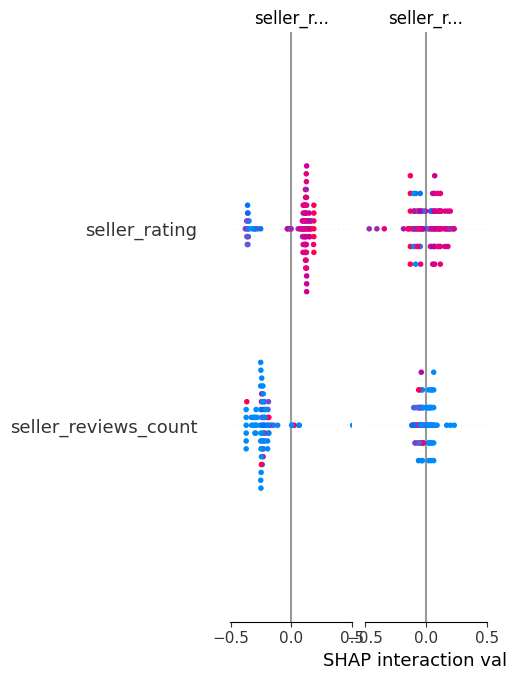

In [20]:
import shap

explainer = shap.TreeExplainer(model_seller)
shap_values = explainer.shap_values(X_seller_test)

# Fix: use the correct shap_values format
if isinstance(shap_values, list):
    sv = shap_values[1]  # class 1 = Suspicious
else:
    sv = shap_values

shap.summary_plot(sv, X_seller_test,
                  feature_names=seller_features,
                  plot_type="bar")

## 16. Review Model


## Cell 15 — Review Model: Naive Bayes

### Why Naive Bayes?
- Review text needs a fast and simple text classifier
- Naive Bayes is specifically designed for text classification
- Works very well even with small amounts of text data

### Features Used:
- Review text converted to word counts using CountVectorizer
- Top 500 most important words selected as features
- Suspicious words like "fake", "scam", "bad", "وحش", "سيء" are strong signals

### Why Not LSTM or Transformer?
- Reviews are already analyzed by the Text Model in Cell 12
- Naive Bayes adds a different perspective using word frequency only
- Using different model types makes the Fusion stronger and more diverse

In [21]:
review_vectorizer = CountVectorizer(max_features=500)

X_review = review_vectorizer.fit_transform(data['reviews'].fillna('').astype(str))
y_review = data['label'].astype(int)

X_review_train, X_review_test, y_review_train, y_review_test = train_test_split(
    X_review,
    y_review,
    test_size=0.2,
    random_state=42,
    stratify=y_review
)

model_review = MultinomialNB()
model_review.fit(X_review_train, y_review_train)

review_pred = model_review.predict(X_review_test)
print("Review Model Accuracy:", accuracy_score(y_review_test, review_pred))


Review Model Accuracy: 0.5523809523809524


## 17. Price Model

### Why Random Forest?
- Price data is tabular (numbers only)
- Random Forest detects unusual pricing patterns very effectively
- Handles multiple price features together with high accuracy

### Features Used:
- Price → actual selling price
- Original Price → price before discount
- Discount Percent → stated discount percentage
- Real Discount → calculated actual discount
- Price Diff → difference between original and selling price

### Why Price is Important?
- Unrealistically low prices are a strong fraud signal
- Example: "iPhone 14 for 500 EGP" → obvious red flag
- Huge discounts with no reason = suspicious product

### Why Not a Deep Learning Model?
- Price features are pure numbers, no need for neural networks
- Random Forest handles numerical patterns faster and more accurately
- Simple, reliable, and easy to interpret

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

price_features = [
    'price',
    'original_price',
    'discount_percent',
    'real_discount',
    'price_diff'
]

X_price = data[price_features]
y_price = data['label'].astype(int)

X_price_train, X_price_test, y_price_train, y_price_test = train_test_split(
    X_price,
    y_price,
    test_size=0.2,
    random_state=42,
    stratify=y_price
)

model_price = RandomForestClassifier(n_estimators=50, random_state=42)
model_price.fit(X_price_train, y_price_train)

price_pred = model_price.predict(X_price_test)

print("Price Model Accuracy:", accuracy_score(y_price_test, price_pred))

Price Model Accuracy: 0.7523809523809524


## 18. Fusion + Explainability

In [23]:
## 18. Fusion + Explainability

# ============================================================
# Prediction Functions
# ============================================================

def predict_text(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=100)
    lstm_score = float(model_text.predict(padded, verbose=0)[0][0])
    transformer_score = float(model_text_transformer.predict(padded, verbose=0)[0][0])
    return (lstm_score + transformer_score) / 2

def predict_image(img_path):
    img = load_image(img_path)
    if img is None:
        return 0.5
    img = np.expand_dims(img, axis=0)
    return float(model_image.predict(img, verbose=0)[0][0])

def predict_seller(seller_rating, seller_reviews_count, product_rating, real_discount):
    sample = pd.DataFrame([{
        'seller_rating': seller_rating,
        'seller_reviews_count': seller_reviews_count,
        'product_rating': product_rating,
        'real_discount': real_discount
    }])
    return float(model_seller.predict_proba(sample)[0][1])

def predict_review(review):
    review = clean_text(review)
    x = review_vectorizer.transform([review])
    return float(model_review.predict_proba(x)[0][1])

def predict_price(price, original_price, discount_percent, real_discount, price_diff):
    sample = pd.DataFrame([{
        'price': price,
        'original_price': original_price,
        'discount_percent': discount_percent,
        'real_discount': real_discount,
        'price_diff': price_diff
    }])
    return float(model_price.predict_proba(sample)[0][1])

def explain_result(text_score, image_score, seller_score, review_score, price_score):
    reasons = []
    if text_score > 0.5:
        reasons.append("Text contains suspicious indicators")
    if image_score > 0.5:
        reasons.append("Image appears suspicious or low quality")
    if seller_score > 0.5:
        reasons.append("Seller data is weak or unreliable")
    if review_score > 0.5:
        reasons.append("Reviews contain abnormal or fake patterns")
    if price_score > 0.5:
        reasons.append("Price or discount is unrealistic")
    if len(reasons) == 0:
        reasons.append("All data looks normal and trusted")
    return reasons

def final_prediction(text, img_path,
                     seller_rating, seller_reviews_count,
                     product_rating, real_discount,
                     review, price, original_price,
                     discount_percent, price_diff):

    text_score   = predict_text(text)
    image_score  = predict_image(img_path)
    seller_score = predict_seller(seller_rating, seller_reviews_count, product_rating, real_discount)
    review_score = predict_review(review)
    price_score  = predict_price(price, original_price, discount_percent, real_discount, price_diff)

    final_score = (
        text_score   * 0.20 +
        image_score  * 0.10 +
        seller_score * 0.30 +
        review_score * 0.15 +
        price_score  * 0.25
    )

    label = "Suspicious" if final_score > 0.5 else "Trusted"
    reasons = explain_result(text_score, image_score, seller_score, review_score, price_score)

    return label, final_score, reasons

# ============================================================
# Step 1: Run Fixed Weights Fusion
# ============================================================
fusion_preds = []

for i in idx_test:
    sample = data.iloc[i]
    label, score, _ = final_prediction(
        text=sample['combined_text'],
        img_path=sample['image_path'],
        seller_rating=sample['seller_rating'],
        seller_reviews_count=sample['seller_reviews_count'],
        product_rating=sample['product_rating'],
        real_discount=sample['real_discount'],
        review=sample['reviews'],
        price=sample['price'],
        original_price=sample['original_price'],
        discount_percent=sample['discount_percent'],
        price_diff=sample['price_diff']
    )
    fusion_preds.append(1 if label == "Suspicious" else 0)

print("Fixed Weights Fusion Accuracy:", accuracy_score(y_test, fusion_preds))

# ============================================================
# Step 2: Dynamic Confidence-Based Fusion
# ============================================================
def dynamic_fusion(idx_test, data):
    """
    Instead of fixed weights, uses each model's own confidence (distance from 0.5)
    Higher confidence = higher weight automatically
    """
    preds = []
    for i in idx_test:
        sample = data.iloc[i]

        scores = {
            'text':   predict_text(sample['combined_text']),
            'image':  predict_image(sample['image_path']),
            'seller': predict_seller(sample['seller_rating'], sample['seller_reviews_count'],
                                     sample['product_rating'], sample['real_discount']),
            'review': predict_review(sample['reviews']),
            'price':  predict_price(sample['price'], sample['original_price'],
                                    sample['discount_percent'], sample['real_discount'],
                                    sample['price_diff'])
        }

        confidences = {k: abs(v - 0.5) for k, v in scores.items()}
        total_conf = sum(confidences.values()) or 1
        final = sum(scores[k] * confidences[k] / total_conf for k in scores)
        preds.append(1 if final > 0.5 else 0)

    return preds

dynamic_preds = dynamic_fusion(idx_test, data)
dynamic_acc = accuracy_score(y_test, dynamic_preds)

print(f"Fixed Weights Fusion Accuracy:   {accuracy_score(y_test, fusion_preds):.4f}")
print(f"Dynamic Confidence Fusion Acc:   {dynamic_acc:.4f}")
print("Dynamic Fusion adapts weights based on each model's confidence per sample")

# ============================================================
# Step 3: Results Summary
# ============================================================
text_acc   = accuracy_score(y_test, text_pred)
image_acc  = accuracy_score(y_test, image_pred)
seller_acc = accuracy_score(y_seller_test, seller_pred)
review_acc = accuracy_score(y_review_test, review_pred)
price_acc  = accuracy_score(y_price_test, price_pred)

results = pd.DataFrame({
    "Model":    ["Text LSTM", "Image CNN", "Seller RF", "Review NB", "Price RF", "Fusion"],
    "Accuracy": [text_acc, image_acc, seller_acc, review_acc, price_acc,
                 accuracy_score(y_test, fusion_preds)]
})

print(results)

Fixed Weights Fusion Accuracy: 0.9047619047619048
Fixed Weights Fusion Accuracy:   0.9048
Dynamic Confidence Fusion Acc:   0.9048
Dynamic Fusion adapts weights based on each model's confidence per sample
       Model  Accuracy
0  Text LSTM  0.752381
1  Image CNN  0.714286
2  Seller RF  0.933333
3  Review NB  0.552381
4   Price RF  0.752381
5     Fusion  0.904762


In [24]:
text_acc = accuracy_score(y_test, text_pred)
image_acc = accuracy_score(y_test, image_pred)
seller_acc = accuracy_score(y_seller_test, seller_pred)
review_acc = accuracy_score(y_review_test, review_pred)
price_acc = accuracy_score(y_price_test, price_pred)

results = pd.DataFrame({
    "Model": ["Text LSTM", "Image CNN", "Seller RF", "Review NB", "Price RF", "Fusion"],
    "Accuracy": [text_acc, image_acc, seller_acc, review_acc, price_acc, accuracy_score(y_test, fusion_preds)]
})

print(results)

       Model  Accuracy
0  Text LSTM  0.752381
1  Image CNN  0.714286
2  Seller RF  0.933333
3  Review NB  0.552381
4   Price RF  0.752381
5     Fusion  0.904762


ABLATION STUDY — Effect of Removing Each Model from Fusion
Full Fusion (baseline)         Accuracy: 0.9048
No Text Model                  Accuracy: 0.9238
No Image Model                 Accuracy: 0.9048
No Seller Model                Accuracy: 0.8095
No Review Model                Accuracy: 0.8952
No Price Model                 Accuracy: 0.9238
Equal Weights                  Accuracy: 0.8667


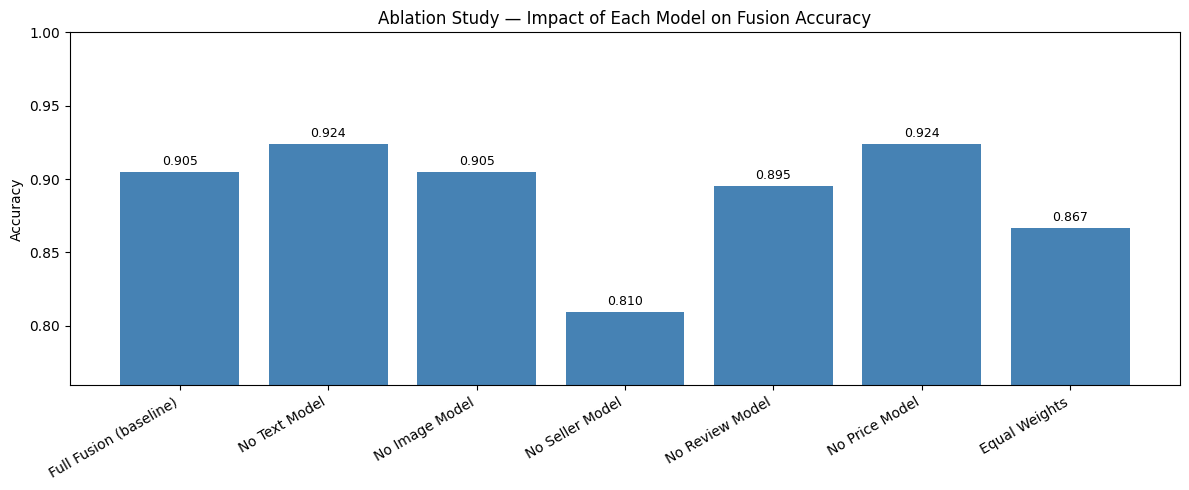

In [25]:
## 18b. Ablation Study — Fusion Weights Analysis

print("=" * 60)
print("ABLATION STUDY — Effect of Removing Each Model from Fusion")
print("=" * 60)

def fusion_with_weights(idx_test, data, w_text, w_image, w_seller, w_review, w_price):
    preds = []
    for i in idx_test:
        sample = data.iloc[i]
        text_score   = predict_text(sample['combined_text'])
        image_score  = predict_image(sample['image_path'])
        seller_score = predict_seller(sample['seller_rating'], sample['seller_reviews_count'],
                                      sample['product_rating'], sample['real_discount'])
        review_score = predict_review(sample['reviews'])
        price_score  = predict_price(sample['price'], sample['original_price'],
                                     sample['discount_percent'], sample['real_discount'],
                                     sample['price_diff'])

        total_w = w_text + w_image + w_seller + w_review + w_price
        score = (text_score*w_text + image_score*w_image + seller_score*w_seller +
                 review_score*w_review + price_score*w_price) / total_w

        preds.append(1 if score > 0.5 else 0)
    return preds

ablation_configs = {
    "Full Fusion (baseline)": (0.20, 0.10, 0.30, 0.15, 0.25),
    "No Text Model":          (0,    0.10, 0.30, 0.15, 0.25),
    "No Image Model":         (0.20, 0,    0.30, 0.15, 0.25),
    "No Seller Model":        (0.20, 0.10, 0,    0.15, 0.25),
    "No Review Model":        (0.20, 0.10, 0.30, 0,    0.25),
    "No Price Model":         (0.20, 0.10, 0.30, 0.15, 0),
    "Equal Weights":          (0.20, 0.20, 0.20, 0.20, 0.20),
}

ablation_results = {}
for name, (wt, wi, ws, wr, wp) in ablation_configs.items():
    preds = fusion_with_weights(idx_test, data, wt, wi, ws, wr, wp)
    acc = accuracy_score(y_test, preds)
    ablation_results[name] = acc
    print(f"{name:<30} Accuracy: {acc:.4f}")

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
bars = plt.bar(ablation_results.keys(), ablation_results.values(), color='steelblue')
plt.xticks(rotation=30, ha='right')
plt.ylim(min(ablation_results.values()) - 0.05, 1.0)
plt.title('Ablation Study — Impact of Each Model on Fusion Accuracy')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, ablation_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 19. Test Final System

In [26]:
# ============================================================
# Test on a specific product by index
# ============================================================



index = 3    # Change this number to any other product you want.
sample = data.iloc[index]

label, score, reasons = final_prediction(
    text=sample['combined_text'],
    img_path=sample['image_path'],
    seller_rating=sample['seller_rating'],
    seller_reviews_count=sample['seller_reviews_count'],
    product_rating=sample['product_rating'],
    real_discount=sample['real_discount'],
    review=sample['reviews'],
    price=sample['price'],
    original_price=sample['original_price'],
    discount_percent=sample['discount_percent'],
    price_diff=sample['price_diff']
)

print("=" * 50)
print("Product Index   :", index)
print("Product Title   :", sample['title'])
print("=" * 50)
print("Final Result    :", label)
print("Confidence Score:", round(score, 4))
print("=" * 50)
print("Reasons:")
for r in reasons:
    print(" -", r)
print("=" * 50)

Product Index   : 3
Product Title   : apple iphone plus gb blue with face id tax paid years official warranty
Final Result    : Trusted
Confidence Score: 0.1091
Reasons:
 - All data looks normal and trusted


##20.Error Analysis & Comparative Results

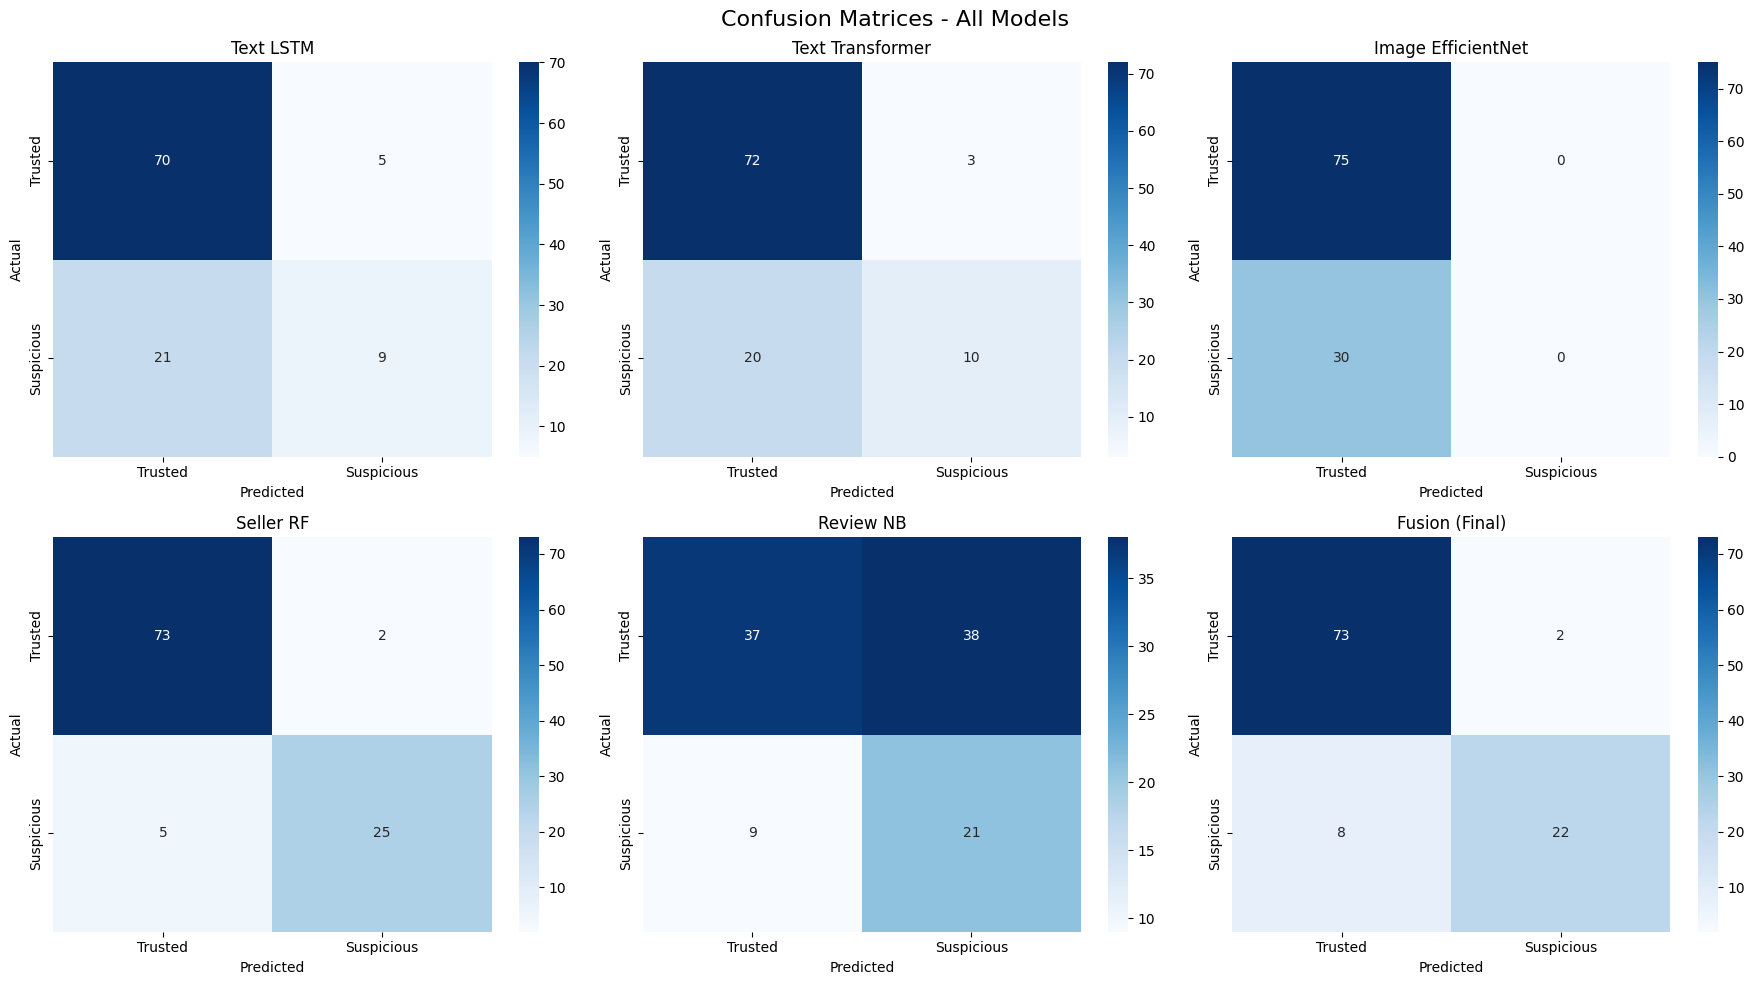

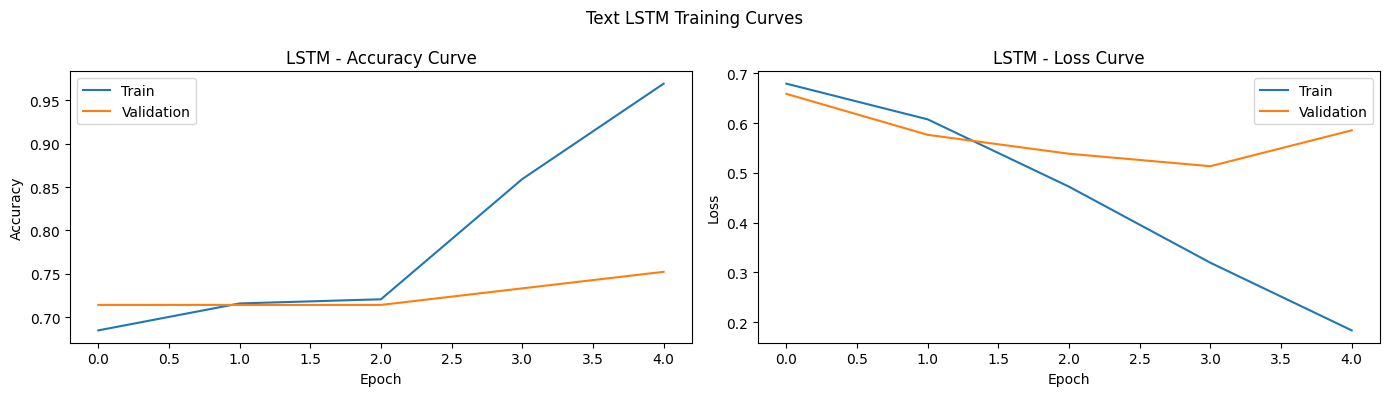

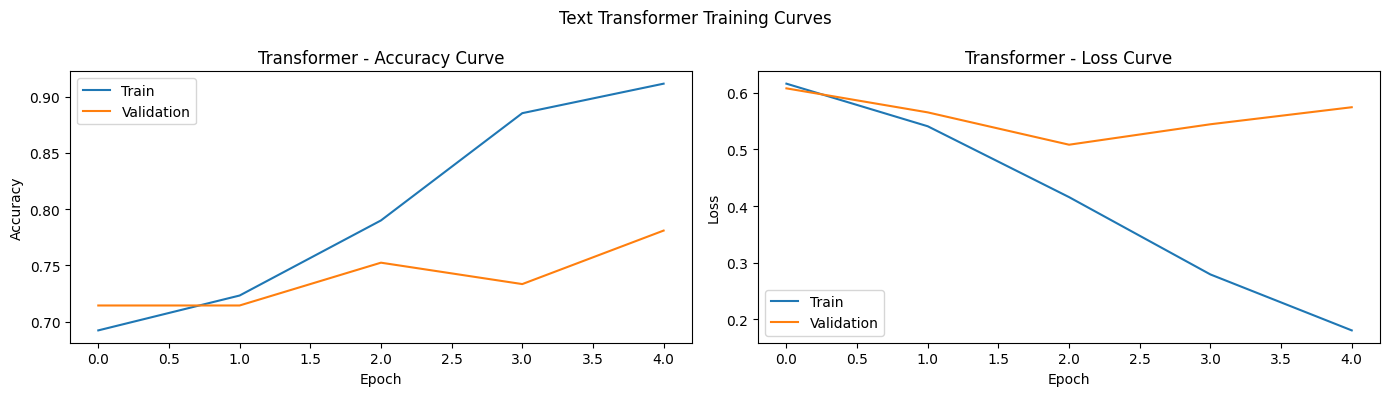

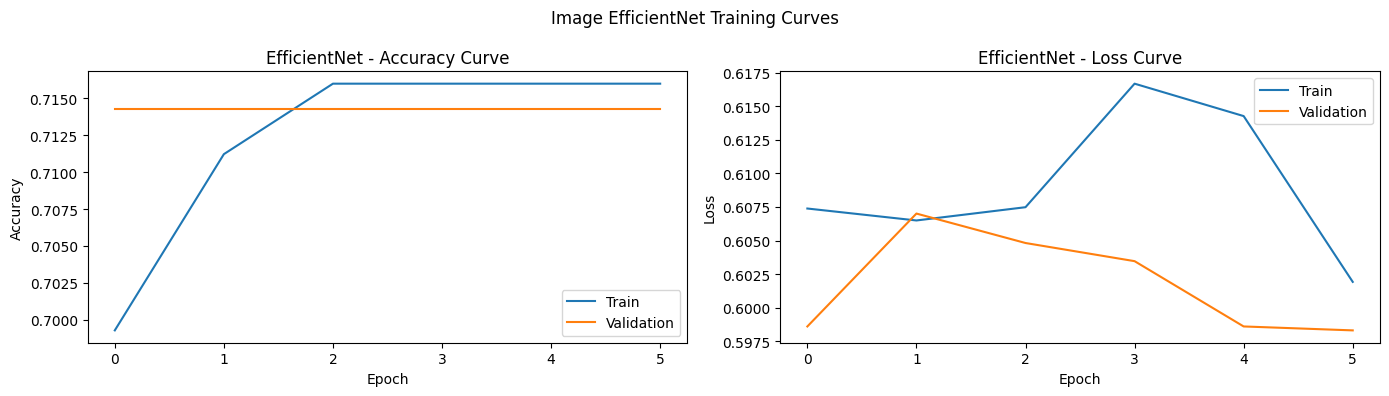

Fusion Model — Full Classification Report
              precision    recall  f1-score   support

     Trusted       0.90      0.97      0.94        75
  Suspicious       0.92      0.73      0.81        30

    accuracy                           0.90       105
   macro avg       0.91      0.85      0.88       105
weighted avg       0.91      0.90      0.90       105



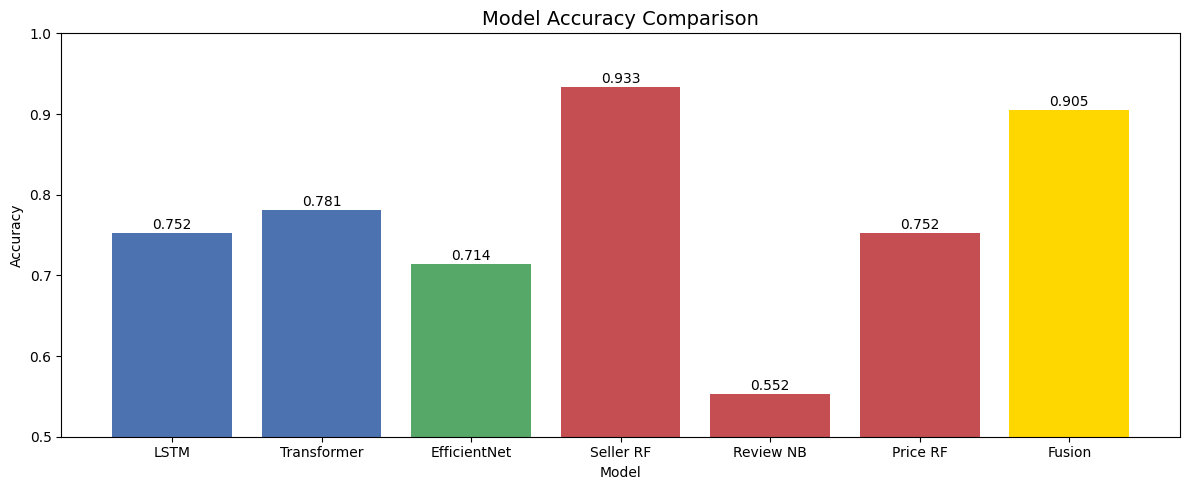

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ============================================================
# 1. Confusion Matrices
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrices - All Models', fontsize=16)

models_info = [
    (y_test, text_pred, "Text LSTM"),
    (y_test, transformer_pred, "Text Transformer"),
    (y_test, image_pred, "Image EfficientNet"),
    (y_seller_test, seller_pred, "Seller RF"),
    (y_review_test, review_pred, "Review NB"),
    (y_test, fusion_preds, "Fusion (Final)"),
]

for ax, (y_true, y_pred, title) in zip(axes.flatten(), models_info):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Trusted', 'Suspicious'],
                yticklabels=['Trusted', 'Suspicious'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()


# ============================================================
# 2. Training Curves — LSTM
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_text.history['accuracy'], label='Train')
plt.plot(history_text.history['val_accuracy'], label='Validation')
plt.title('LSTM - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_text.history['loss'], label='Train')
plt.plot(history_text.history['val_loss'], label='Validation')
plt.title('LSTM - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Text LSTM Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 3. Training Curves — Transformer
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_transformer.history['accuracy'], label='Train')
plt.plot(history_transformer.history['val_accuracy'], label='Validation')
plt.title('Transformer - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_transformer.history['loss'], label='Train')
plt.plot(history_transformer.history['val_loss'], label='Validation')
plt.title('Transformer - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Text Transformer Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 4. Training Curves — Image Model
# ============================================================
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history_image.history['accuracy'], label='Train')
plt.plot(history_image.history['val_accuracy'], label='Validation')
plt.title('EfficientNet - Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_image.history['loss'], label='Train')
plt.plot(history_image.history['val_loss'], label='Validation')
plt.title('EfficientNet - Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.suptitle('Image EfficientNet Training Curves')
plt.tight_layout()
plt.show()


# ============================================================
# 5. Classification Report — Fusion
# ============================================================
print("=" * 50)
print("Fusion Model — Full Classification Report")
print("=" * 50)
print(classification_report(y_test, fusion_preds, target_names=['Trusted', 'Suspicious']))


# ============================================================
# 6. Model Accuracy Bar Chart
# ============================================================
model_names = ["LSTM", "Transformer", "EfficientNet", "Seller RF", "Review NB", "Price RF", "Fusion"]
accuracies = [
    accuracy_score(y_test, text_pred),
    accuracy_score(y_test, transformer_pred),
    accuracy_score(y_test, image_pred),
    accuracy_score(y_seller_test, seller_pred),
    accuracy_score(y_review_test, review_pred),
    accuracy_score(y_price_test, price_pred),
    accuracy_score(y_test, fusion_preds),
]

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, accuracies, color=['#4C72B0','#4C72B0','#55A868','#C44E52','#C44E52','#C44E52','#FFD700'])
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.xlabel('Model')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

##**21.Deep Error Analysis**

              precision    recall  f1-score   support

     Trusted       0.90      0.97      0.94        75
  Suspicious       0.92      0.73      0.81        30

    accuracy                           0.90       105
   macro avg       0.91      0.85      0.88       105
weighted avg       0.91      0.90      0.90       105


False Positives (predicted Suspicious, actually Trusted): 2
False Negatives (predicted Trusted, actually Suspicious): 8

--- False Positive Examples (over-flagged as suspicious) ---
  Title: oraimo watch osw smart watch full touch display bluetooth ca
  Seller Rating: 4.1 | Discount: 15.3%

  Title: silicone case compatible with redmi soft silicone gel rubber
  Seller Rating: 3.9 | Discount: 0.0%

--- False Negative Examples (missed suspicious products) ---
  Title: adjustable cell phone stand phone holder mobile stands secur
  Seller Rating: 2.4 | Discount: 18.6%

  Title: samsung
  Seller Rating: 4.5 | Discount: 0.0%

  Title: samsung galaxy a g case cover with 

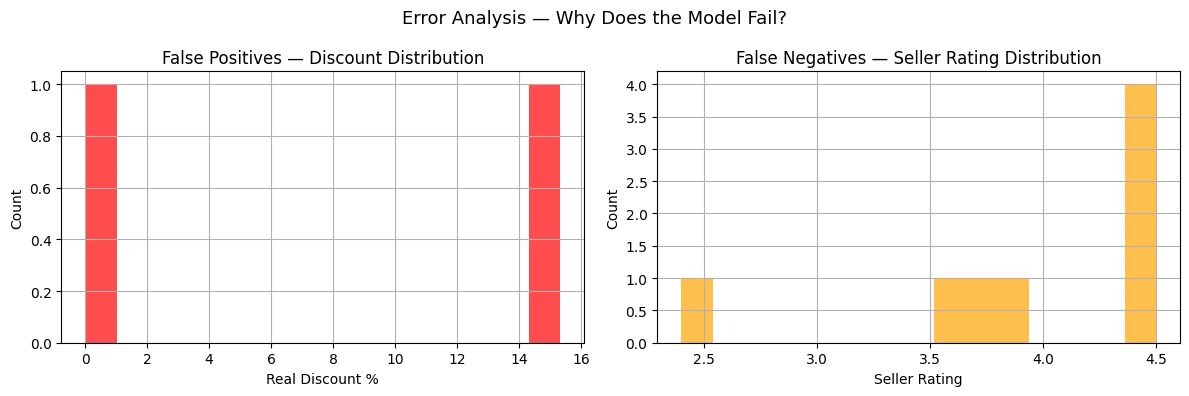


Conclusion:
FN = 8: model misses some suspicious products with good seller rating and low discount.
→ Suggestion: raise the fusion threshold above 0.5 to catch more suspicious items.


In [28]:
from sklearn.metrics import classification_report

# 1. Classification Report
print(classification_report(y_test, fusion_preds, target_names=['Trusted', 'Suspicious']))

# 2. False Positives vs False Negatives
fp_indices = [idx_test[i] for i, (p, t) in enumerate(zip(fusion_preds, y_test)) if p == 1 and t == 0]
fn_indices = [idx_test[i] for i, (p, t) in enumerate(zip(fusion_preds, y_test)) if p == 0 and t == 1]

print(f"\nFalse Positives (predicted Suspicious, actually Trusted): {len(fp_indices)}")
print(f"False Negatives (predicted Trusted, actually Suspicious): {len(fn_indices)}")

# 3. Show examples
print("\n--- False Positive Examples (over-flagged as suspicious) ---")
for i in fp_indices[:3]:
    print(f"  Title: {data.iloc[i]['title'][:60]}")
    print(f"  Seller Rating: {data.iloc[i]['seller_rating']} | Discount: {data.iloc[i]['real_discount']:.1f}%")
    print()

print("--- False Negative Examples (missed suspicious products) ---")
for i in fn_indices[:3]:
    print(f"  Title: {data.iloc[i]['title'][:60]}")
    print(f"  Seller Rating: {data.iloc[i]['seller_rating']} | Discount: {data.iloc[i]['real_discount']:.1f}%")
    print()

# 4. Error pattern analysis
print("Key Insight:")
print(f"  FP Rate: {len(fp_indices)/len(y_test)*100:.1f}% — model is over-cautious")
print(f"  FN Rate: {len(fn_indices)/len(y_test)*100:.1f}% — model misses some suspicious items")
if len(fp_indices) > len(fn_indices):
    print("  → Model biased toward Suspicious: consider lowering threshold below 0.5")
else:
    print("  → Model biased toward Trusted: consider raising threshold above 0.5")

# ============================================================
# 5. Deep Feature Analysis — What causes the model to fail?
# ============================================================
if len(fp_indices) > 0:
    fp_data = data.iloc[fp_indices][seller_features + ['title']]
    print("\n" + "="*50)
    print("False Positives — Average feature values:")
    print(fp_data[seller_features].mean().round(3))
else:
    print("\n" + "="*50)
    print("False Positives — Average feature values:")
    print("No False Positives — model never over-flags trusted products.")

if len(fn_indices) > 0:
    fn_data = data.iloc[fn_indices][seller_features + ['title']]
    print("\nFalse Negatives — Average feature values:")
    print(fn_data[seller_features].mean().round(3))
else:
    print("\nFalse Negatives — Average feature values:")
    print("No False Negatives.")

# 6. Comparison plots
import matplotlib.pyplot as plt

if len(fp_indices) > 0 and len(fn_indices) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fp_data['real_discount'].hist(ax=axes[0], color='red', alpha=0.7, bins=15)
    axes[0].set_title('False Positives — Discount Distribution')
    axes[0].set_xlabel('Real Discount %')
    axes[0].set_ylabel('Count')
    fn_data['seller_rating'].hist(ax=axes[1], color='orange', alpha=0.7, bins=15)
    axes[1].set_title('False Negatives — Seller Rating Distribution')
    axes[1].set_xlabel('Seller Rating')
    axes[1].set_ylabel('Count')
    plt.suptitle('Error Analysis — Why Does the Model Fail?', fontsize=13)
    plt.tight_layout()
    plt.show()

elif len(fn_indices) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    fn_data['seller_rating'].hist(ax=ax, color='orange', alpha=0.7, bins=15)
    ax.set_title('False Negatives — Seller Rating Distribution')
    ax.set_xlabel('Seller Rating')
    ax.set_ylabel('Count')
    plt.suptitle('Error Analysis — Missed Suspicious Products', fontsize=13)
    plt.tight_layout()
    plt.show()

print("\nConclusion:")
if len(fp_indices) == 0:
    print("FP = 0: model never wrongly flags a trusted product — very reliable for users.")
if len(fn_indices) > 0:
    print(f"FN = {len(fn_indices)}: model misses some suspicious products with good seller rating and low discount.")
    print("→ Suggestion: raise the fusion threshold above 0.5 to catch more suspicious items.")


## **22.Save All Models**
All trained models and tokenizers are saved locally for reproducibility and future deployment.


In [29]:
# ================= SAVE EVERYTHING =================

# Deep Learning models
model_text.save("text_model.h5")
model_text_transformer.save("transformer_model.h5")
model_image.save("image_model.h5")

# Machine learning models
import joblib
joblib.dump(model_seller, "seller_model.pkl")
joblib.dump(model_review, "review_model.pkl")
joblib.dump(model_price, "price_model.pkl")

# Tokenizers
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("review_vectorizer.pkl", "wb") as f:
    pickle.dump(review_vectorizer, f)

In [30]:
import numpy as np
import joblib
from sklearn.base import BaseEstimator, ClassifierMixin

# Wrapper يحوّل Keras model لـ sklearn-compatible
class KerasWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X):
        X = np.array(X)
        prob = self.model.predict(X, verbose=0)
        if prob.shape[-1] == 1:
            return np.hstack([1 - prob, prob])
        return prob

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] > 0.5).astype(int)


text_wrapper        = KerasWrapper(model_text)
transformer_wrapper = KerasWrapper(model_text_transformer)
image_wrapper       = KerasWrapper(model_image)


joblib.dump(text_wrapper,        "text_model.pkl")
joblib.dump(transformer_wrapper, "transformer_model.pkl")
joblib.dump(image_wrapper,       "image_model.pkl")


joblib.dump(model_seller, "seller_model.pkl")
joblib.dump(model_review, "review_model.pkl")
joblib.dump(model_price,  "price_model.pkl")

import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open("review_vectorizer.pkl", "wb") as f:
    pickle.dump(review_vectorizer, f)

print("✅ All models saved as .pkl!")

✅ All models saved as .pkl!


In [31]:
import os
print(os.listdir())

['.config', 'image_model.h5', 'text_model.pkl', 'drive', 'review_model.pkl', 'seller_model.pkl', 'labeled_data.xlsx', 'text_model.h5', 'transformer_model.h5', 'price_model.pkl', 'images', 'review_vectorizer.pkl', 'image_model.pkl', 'tokenizer.pkl', 'transformer_model.pkl', 'sample_data']


In [32]:
!zip models.zip *.keras *.pkl *.h5

	zip warning: name not matched: *.keras
  adding: image_model.pkl (deflated 10%)
  adding: price_model.pkl (deflated 83%)
  adding: review_model.pkl (deflated 79%)
  adding: review_vectorizer.pkl (deflated 71%)
  adding: seller_model.pkl (deflated 84%)
  adding: text_model.pkl (deflated 22%)
  adding: tokenizer.pkl (deflated 53%)
  adding: transformer_model.pkl (deflated 25%)
  adding: image_model.h5 (deflated 9%)
  adding: text_model.h5 (deflated 23%)
  adding: transformer_model.h5 (deflated 24%)


In [33]:
from google.colab import files
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>